**Regime Analysis**

Which such a large and near-random data set, total averages are not as useful. Instead analylists will split the market into bull, bear and crisis regime.

A crisis regime is when the market is completely unpredictable, when investors are afraid to invest. In this model we categorize all VIX > 30 as crisis regime.

A Bull regime is when the market is moving upwards consistently, and investors are willing to put money into the market. This model we categorize a bullish market as when the VIX is less than 20, and if the S&P is currently greater than its average for the last 200 days.

A Bear regime is the inbetwen scenario, where it is not at a total crisis point, but investor's faith is not totally secure in the market.

=== REGIME SAMPLE SIZES ===
Bull   Regime:  2724 days (69.83%)
Bear   Regime:   944 days (24.20%)
Crisis Regime:   233 days (5.97%)



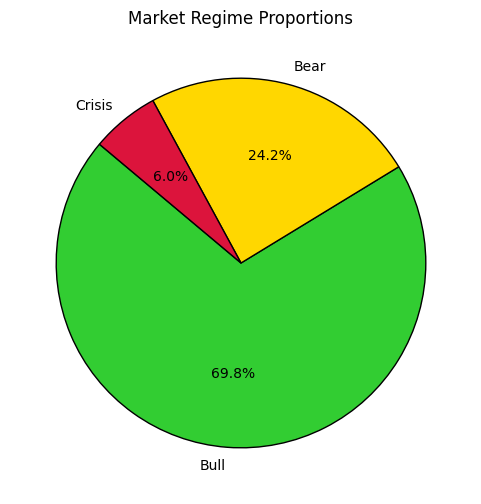

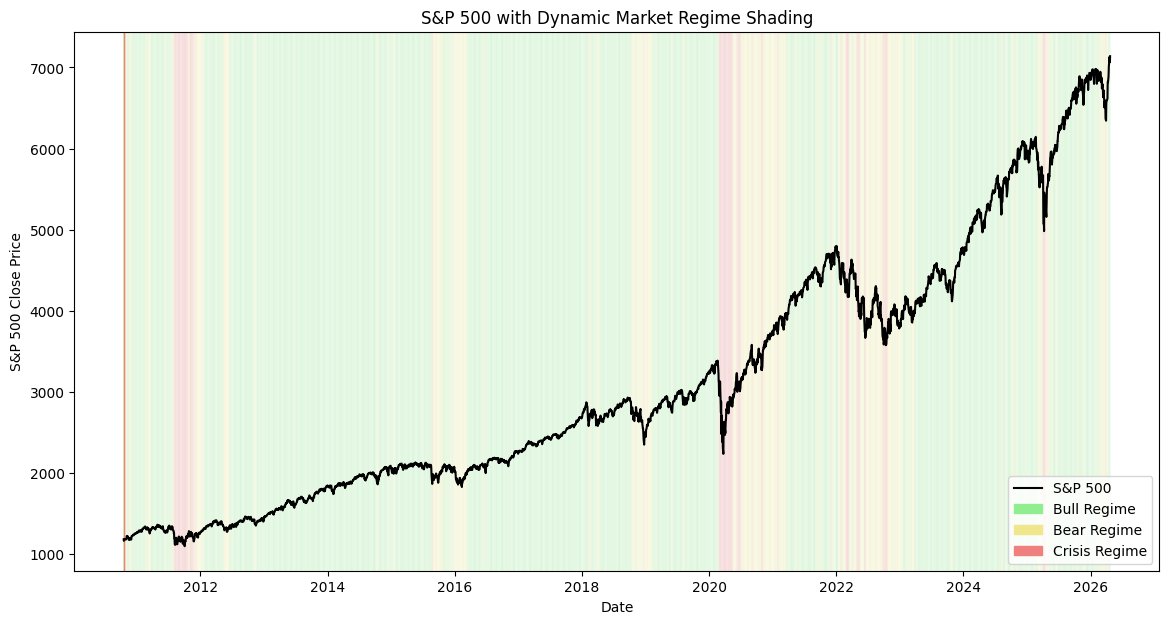

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/master_dataset.csv', index_col='Date', parse_dates=True)

# rollingAverage
df['spx_sma200'] = df['spx_close'].rolling(window=200).mean()


def determine_regime(row):
    # Skip first 200 rows
    if pd.isna(row['spx_sma200']):
        return np.nan

    if row['vix_decimal'] >= 0.30:
        return 'Crisis'
    elif row['spx_close'] > row['spx_sma200'] and row['vix_decimal'] < 0.20:
        return 'Bull'
    else:
        return 'Bear'

df['regime'] = df.apply(determine_regime, axis=1)
df_clean = df.dropna(subset=['regime']).copy()
regime_colors = {'Bull': 'green', 'Bear': 'khaki', 'Crisis': 'crimson'}

regime_counts = df_clean['regime'].value_counts()
regime_pcts = df_clean['regime'].value_counts(normalize=True) * 100

def shade_regime_blocks(ax, data, color_map, alpha=0.08):
    regime_blocks = (data['regime'] != data['regime'].shift()).cumsum()
    for _, block in data.groupby(regime_blocks):
        regime_name = block['regime'].iloc[0]
        start = block.index[0]
        end = block.index[-1]
        ax.axvspan(start, end, color=color_map[regime_name], alpha=alpha, zorder=0)

print("=== REGIME SAMPLE SIZES ===")
for reg in ['Bull', 'Bear', 'Crisis']:
    count = regime_counts.get(reg, 0)
    pct = regime_pcts.get(reg, 0)
    print(f"{reg:6} Regime: {count:5} days ({pct:.2f}%)")
print("===========================\n")

# pieChart
plt.figure(figsize=(6, 6))
plt.pie(regime_counts, labels=regime_counts.index, autopct='%1.1f%%',
        colors=[regime_colors[reg] for reg in regime_counts.index], startangle=140,
        wedgeprops={'edgecolor': 'black'})
plt.title('Market Regime Proportions')
plt.show()

# Plot S&P 500 with dynamic background shading for regimes
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df_clean.index, df_clean['spx_close'], color='black', label='S&P 500', linewidth=1.5)

shade_regime_blocks(ax, df_clean, regime_colors)

for regime_name, color in regime_colors.items():
    ax.axvspan(df_clean.index[0], df_clean.index[0], color=color, label=f'{regime_name} Regime')

ax.set_title('S&P 500 with Dynamic Market Regime Shading')
ax.set_ylabel('S&P 500 Close Price')
ax.set_xlabel('Date')
ax.legend()
plt.show()

**Win Rate**

an option seller wins when the VRP is positive. This is because the cost of insurance (VIX) was greater than the actual payout (Realized Volatility). We can now look at the split the data on regime, and see where the highest win rates are.

=== CROSS-REGIME STATISTICAL SUMMARY ===
            mean    median  count  win_rate (%)
regime                                         
Bear    0.048521  0.062833    944     82.521186
Bull    0.025103  0.036871   2724     83.149780
Crisis  0.081600  0.100548    233     93.562232



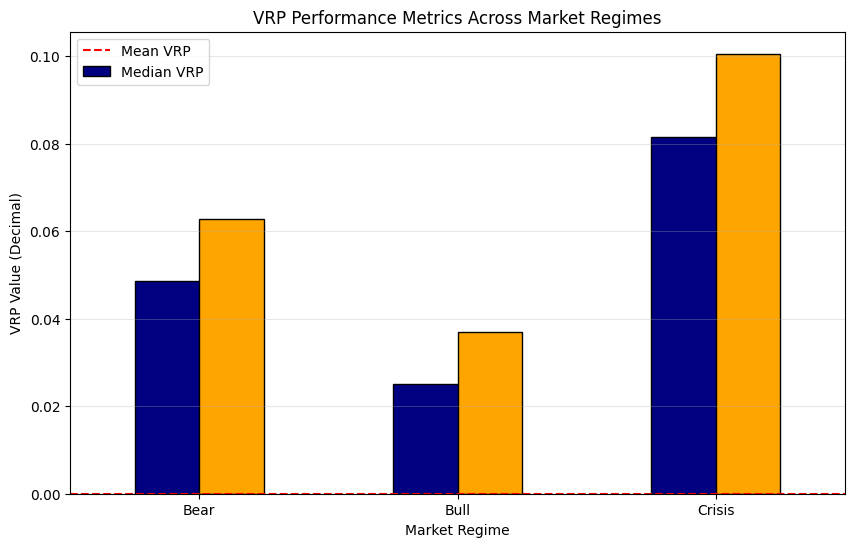

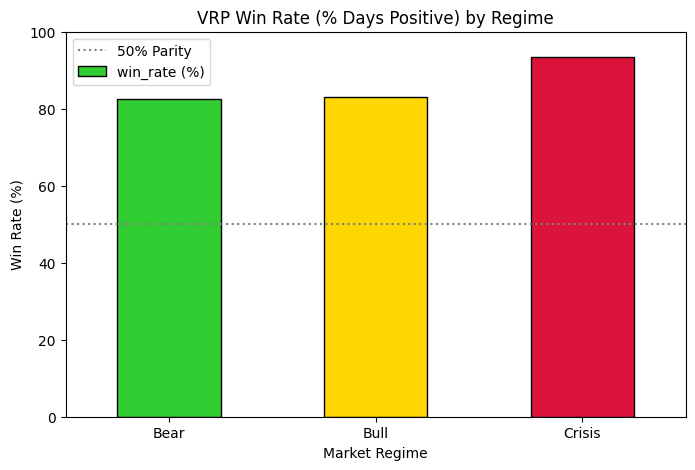

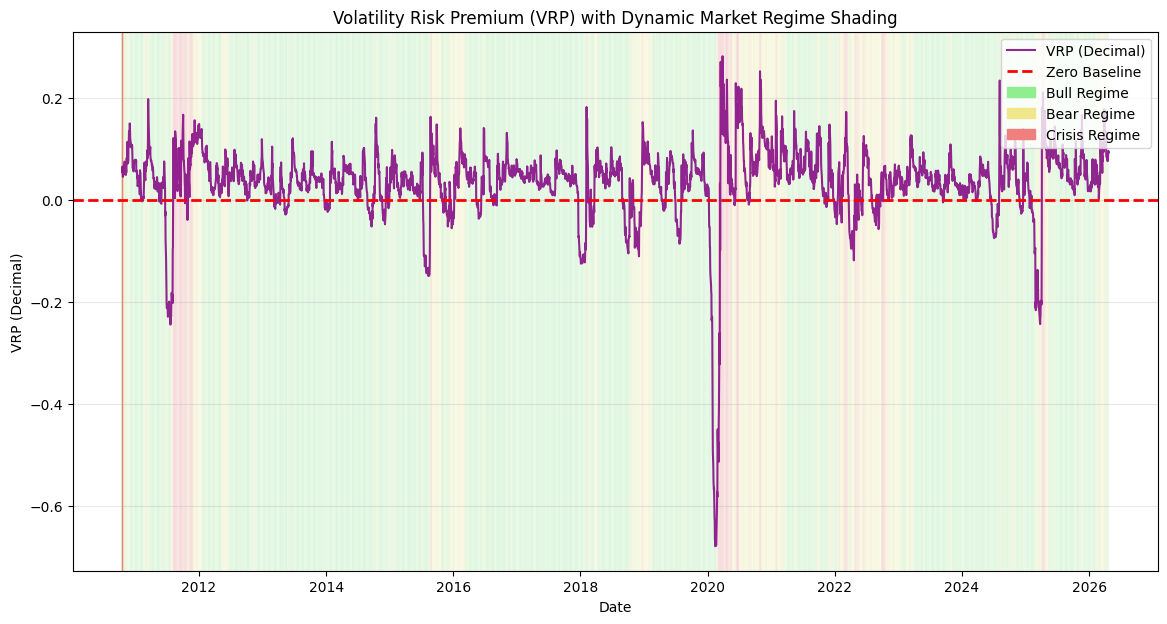

In [12]:
# computeVRP
df_clean['vrp'] = df_clean['vix_decimal'] - df_clean['forward_realized_vol']

# groupStatsByRegime
regime_stats = df_clean.groupby('regime')['vrp'].agg(['mean', 'median', 'count'])

# calculateWinRate
win_rates = df_clean.groupby('regime').apply(lambda x: (x['vrp'] > 0).mean() * 100)
regime_stats['win_rate (%)'] = win_rates

print("=== CROSS-REGIME STATISTICAL SUMMARY ===")
print(regime_stats)
print("========================================\n")

# VRP across regimes
regime_stats[['mean', 'median']].plot(kind='bar', figsize=(10, 6), color=['navy', 'orange'], edgecolor='black')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('VRP Performance Metrics Across Market Regimes')
plt.ylabel('VRP Value (Decimal)')
plt.xlabel('Market Regime')
plt.xticks(rotation=0)
plt.legend(['Mean VRP', 'Median VRP'])
plt.grid(axis='y', alpha=0.3)
plt.show()

# Win Rates across regimes
plt.figure(figsize=(8, 5))
regime_stats['win_rate (%)'].plot(kind='bar', color=[regime_colors[reg] for reg in regime_stats.index], edgecolor='black')
plt.axhline(50, color='grey', linestyle=':', label='50% Parity')
plt.title('VRP Win Rate (% Days Positive) by Regime')
plt.ylabel('Win Rate (%)')
plt.xlabel('Market Regime')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend()
plt.show()

# plotRegimeShadedVRP
fig, ax = plt.subplots(figsize=(14, 7))

# Plot VRP daily line
ax.plot(df_clean.index, df_clean['vrp'], color='purple', label='VRP (Decimal)', linewidth=1.5, alpha=0.85)

# Add horizontal zero line
ax.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Baseline')

# Shading background by contiguous regime blocks
shade_regime_blocks(ax, df_clean, regime_colors)

# Dummy plots for legend
for regime_name, color in regime_colors.items():
    ax.axvspan(df_clean.index[0], df_clean.index[0], color=color, label=f'{regime_name} Regime')

ax.set_title('Volatility Risk Premium (VRP) with Dynamic Market Regime Shading')
ax.set_ylabel('VRP (Decimal)')
ax.set_xlabel('Date')
ax.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()